##  Setup — the modern stack 

In [1]:
import gymnasium as gym; 
print('gymnasium', gym.__version__)

gymnasium 1.3.0


In [2]:
# Create the FrozenLake environment.
# "FrozenLake-v1" is the environment ID for a simple tabular (grid-based) environment.
# is_slippery=True means agent movements are stochastic (actions may slip to unintended directions).
env = gym.make(
    "FrozenLake-v1",          # str: environment ID; chooses the built-in FrozenLake MDP
    is_slippery=True         # bool: if True, agent moves are noisy/stochastic (slip happens)
)

# Reset the environment to start a new episode.
# Returns a tuple: (observation, info)
# - seed=0: sets the random seed (for deterministic resets)
# - observation: the initial discrete state (position in grid)
# - info: dict with additional info (e.g., for debugging, diagnostics)
obs, info = env.reset(seed=0)

# Take a single action in the environment.
# env.action_space.sample(): randomly sample a valid action.
# For FrozenLake, actions are integers from 0 to 3 because there are 4 possible movement directions (left, down, right, up).
# step(action) returns tuple: (observation, reward, terminated, truncated, info)
# - observation: new state after action
# - reward: the numerical reward for this transition
# - terminated: True if episode ended due to success/failure (e.g., goal reached or fell in hole)
# - truncated: True if episode ended due to time limit or truncation condition
# - info: dict with auxiliary info
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

# Note: Episode ends if either terminated or truncated is True.

# For tabular environments like FrozenLake, the full transition model is exposed as:
# env.unwrapped.P[state][action] = [(prob, next_state, reward, done), ...]
# where:
#   - state: current discrete state (int)
#   - action: discrete action (int)
#   - prob: probability of this transition
#   - next_state: discrete next state (int)
#   - reward: reward obtained from this transition
#   - done: whether the episode ends after this transition

##  Problem 1 — Build the Mars Rover environment

A $5 \times 5$ dusty crater field. The rover starts at $(0,0)$, must reach the science target at $(4,4)$ (reward $+10$, episode ends), and must avoid two craters at $(2,2)$ and $(1,3)$ (reward $-10$, episode ends).

Every move costs $-1$:

$$
r(s, a, s') =
  \begin{cases}
    +10 & \text{if } s' = (4,4) \\
    -10 & \text{if } s' \in \{(2,2),\, (1,3)\} \\
    -1  & \text{otherwise}
  \end{cases}
$$

The terrain is dusty: the rover moves in the intended direction with probability $0.8$, and slips to each perpendicular direction with probability $0.1$:

$$
P(s' \mid s,a) =
  \begin{cases}
    0.8 & \text{if $s'$ is the state reached by intended action} \\
    0.1 & \text{if $s'$ is the state reached by one of the two perpendicular actions} \\
    0   & \text{otherwise}
  \end{cases}
$$

Discount factor: $\gamma = 0.95$.

States: $25$ cells $\big(s = 5 \cdot \text{row} + \text{col}\big)$.  
Actions: $0 = \text{up},\ 1 = \text{right},\ 2 = \text{down},\ 3 = \text{left}$.

In [3]:
from typing import Tuple, Dict, List, Optional, Any


# Define the size of the grid world: 5x5
GRID: int = 5

# The coordinates (row, col) of the goal state
GOAL: Tuple[int, int] = (4, 4)

# The set of coordinates (row, col) of the craters (these are bad states)
CRATERS: set[Tuple[int, int]] = {(2, 2), (1, 3)}

# The probability that the rover "slips" to a perpendicular direction instead of moving as intended.
# For each action, the rover has probability SLIP of slipping to either perpendicular direction,
# and probability (1 - 2*SLIP) of moving as intended.
SLIP: float = 0.1

# The discount factor for reward in value computation
GAMMA: float = 0.95

# MOVES dictionary maps each action integer to a tuple (delta_row, delta_col):
#   0: move up    (-1, 0)
#   1: move right (0, 1)
#   2: move down  (1, 0)
#   3: move left  (0, -1)
MOVES: Dict[int, Tuple[int, int]] = {
    0: (-1, 0),   # up    (row decreases)
    1: (0, 1),    # right (col increases)
    2: (1, 0),    # down  (row increases)
    3: (0, -1)    # left  (col decreases)
}


# PERP dictionary tells the action indices for the two perpendicular "slip" directions
PERP: Dict[int, List[int]] = {
    0: [3, 1],    # if move up, you can slip left or right
    1: [0, 2],    # if move right, slip up or down
    2: [1, 3],    # if move down, slip right or left
    3: [2, 0]     # if move left, slip down or up
}

def rc(s: int) -> Tuple[int, int]:
    """
    rc(s): Given a state index s (0 to GRID*GRID-1), returns (row, col)
    """
    # equivalent to (a // b, a % b)
    return divmod(s, GRID)

def idx(r: int, c: int) -> int:
    """
    idx(r, c): Given (row, col), returns the flattened state index s
    """
    return r * GRID + c



In [4]:
from gymnasium import spaces
class MarsRoverEnv(gym.Env):
    """
    Defines the Mars Rover environment:
    - The rover starts at (0, 0)
    - The goal is at (4, 4) (reward +10, ends episode)
    - There are craters at (2, 2) and (1, 3) (reward -10, ends episode)
    - Each move costs -1 (unless ending in goal/crater)
    - Board has 5x5 grid = 25 states
    - Actions: 0 (up), 1 (right), 2 (down), 3 (left)
    - Movement is stochastic due to 'SLIP'
    """

    def __init__(self) -> None:
        super().__init__()
        # State space: 25 discrete states (each cell)
        self.observation_space = spaces.Discrete(GRID * GRID)
        # Action space: 4 discrete actions (up, right, down, left)
        self.action_space = spaces.Discrete(4)
        # Compute the flattened index for the goal state
        self.goal: int = idx(*GOAL)
        # Set of flattened indices for each crater
        self.craters: set[int] = {idx(*c) for c in CRATERS}
        # All terminal states: goal and all craters (episode ends if reached)
        self.terminals: set[int] = self.craters | {self.goal}
        # The transition model for the environment, built in advance
        self.P: Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]] = self._build_model()

    def _move(self, s: int, a: int) -> int:
        """
        Given current state `s` (flattened index) and action `a`,
        computes the resulting state index after attempting to move.
        If the move would leave the board, stays at the border.

        Args:
            s (int): Current state index
            a (int): Action index

        Returns:
            int: Next state index
        """
        r, c = rc(s)         # Convert index to (row, col)
        dr, dc = MOVES[a]    # Get movement delta for this action
        new_r = min(max(r + dr, 0), GRID - 1)
        new_c = min(max(c + dc, 0), GRID - 1)
        return idx(new_r, new_c)

    def _reward(self, s_next: int) -> float:
        """
        Computes the reward for entering state s_next:
        +10 if it's the goal,
        -10 if it's a crater,
        -1 otherwise (for moving to a regular cell)

        Args:
            s_next (int): Next state index

        Returns:
            float: Reward for transitioning to s_next
        """
        if s_next == self.goal:
            return 10.0
        elif s_next in self.craters:
            return -10.0
        else:
            return -1.0

    def _build_model(self) -> Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]]:
        """
        Constructs the full transition probability model for the environment:
        For each state s and action a, returns a nested dict mapping each state and action
        to a list of (probability, next_state, reward, is_terminal) tuples.

        Returns:
            Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]]:
                Transition model
        """
        P: Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]] = {s: {a: [] for a in range(4)} for s in range(GRID * GRID)}
        for s in range(GRID * GRID):
            for a in range(4):
                if s in self.terminals:
                    # Terminal state: all actions keep you in the same state (absorbing), zero reward
                    P[s][a] = [(1.0, s, 0.0, True)]
                    continue
                outcomes: Dict[int, float] = dict()  # Maps next_state -> total probability for each possible result

                # Main (intended) direction:
                intended = self._move(s, a)  # State you'd get if not slipping
                # Get current probability for intended outcome, or 0 if not present
                outcomes[intended] = outcomes.get(intended, 0) + (1 - 2 * SLIP)

                # Perpendicular slips: loop through the two perpendicular action indices
                for slip_a in PERP[a]:
                    slipped = self._move(s, slip_a)
                    # Add probability of slipping to this outcome
                    outcomes[slipped] = outcomes.get(slipped, 0) + SLIP

                P[s][a] = [
                    (p, sn, self._reward(sn), sn in self.terminals)
                    for sn, p in outcomes.items()
                ]
        return P

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None) -> Tuple[int, dict]:
        """
        Resets the environment to the starting state (top-left cell),
        always (0, 0) => state index 0.

        Args:
            seed (Optional[int], optional): Random seed. Defaults to None.
            options (Optional[dict], optional): Additional options. Defaults to None.

        Returns:
            Tuple[int, dict]: Starting state and info dict (empty)
        """
        super().reset(seed=seed)
        self.s: int = idx(0, 0)
        return self.s, {}

    def step(self, action: int) -> Tuple[int, float, bool, bool, dict]:
        """
        Take an action from the current state, using the precomputed transition model:
        - Sample one of the possible outcomes (using their probabilities)
        - Update the current state
        - Return new state, reward, episode termination, truncated flag, and info dict

        Args:
            action (int): The action to take

        Returns:
            Tuple[int, float, bool, bool, dict]: (next_state, reward, terminated, truncated, info dict)
        """
        tr = self.P[self.s][action]  # List of possible transitions (prob, next_state, reward, done)
        # Randomly select an outcome according to transition probabilities
        i = self.np_random.choice(len(tr), p=[t[0] for t in tr])
        _, s_next, reward, terminated = tr[i]
        self.s = s_next  # Update current state
        # Return next_state, reward, terminated, truncated(False), and empty info dict
        return s_next, reward, terminated, False, {}


In [5]:
# Register and run it with a random policy for one episode; print each (s, a, reward, s_next). 
# Confirm step() returns the 5-tuple and the episode ends at a crater or the goal

import numpy as np

# Helper: render state as (row, col)
def state_str(s):
    r, c = divmod(s, GRID)
    return f"({r},{c})"

# Create and seed environment
env = MarsRoverEnv()
obs, info = env.reset(seed=42)
done = False
steps = 0

print("Episode trace (s, a, reward, s_next):")
while not done and steps < 100:
    s = obs
    a = env.action_space.sample()
    obs_next, r, terminated, truncated, _ = env.step(a)
    print(f"s={state_str(s):>6}  a={a}  r={r:>5}  s_next={state_str(obs_next):>6}")
    obs = obs_next
    done = terminated or truncated
    steps += 1
    if done:
        print("Episode finished (goal or crater).\n")

Episode trace (s, a, reward, s_next):
s= (0,0)  a=0  r= -1.0  s_next= (0,0)
s= (0,0)  a=1  r= -1.0  s_next= (0,1)
s= (0,1)  a=1  r= -1.0  s_next= (0,1)
s= (0,1)  a=1  r= -1.0  s_next= (0,2)
s= (0,2)  a=2  r= -1.0  s_next= (1,2)
s= (1,2)  a=2  r= -1.0  s_next= (1,1)
s= (1,1)  a=3  r= -1.0  s_next= (1,0)
s= (1,0)  a=0  r= -1.0  s_next= (0,0)
s= (0,0)  a=2  r= -1.0  s_next= (1,0)
s= (1,0)  a=1  r= -1.0  s_next= (1,1)
s= (1,1)  a=3  r= -1.0  s_next= (1,0)
s= (1,0)  a=1  r= -1.0  s_next= (2,0)
s= (2,0)  a=0  r= -1.0  s_next= (1,0)
s= (1,0)  a=1  r= -1.0  s_next= (0,0)
s= (0,0)  a=3  r= -1.0  s_next= (0,0)
s= (0,0)  a=2  r= -1.0  s_next= (1,0)
s= (1,0)  a=1  r= -1.0  s_next= (1,1)
s= (1,1)  a=0  r= -1.0  s_next= (0,1)
s= (0,1)  a=0  r= -1.0  s_next= (0,0)
s= (0,0)  a=2  r= -1.0  s_next= (1,0)
s= (1,0)  a=0  r= -1.0  s_next= (0,0)
s= (0,0)  a=3  r= -1.0  s_next= (0,0)
s= (0,0)  a=1  r= -1.0  s_next= (1,0)
s= (1,0)  a=0  r= -1.0  s_next= (1,0)
s= (1,0)  a=0  r= -1.0  s_next= (0,0)
s= (0,0)  a=

### Why does the env build self.P (the full transition model)? Which of the three algorithms will be allowed to read it, and which two are forbidden from touching it?

**Answer:**

The environment builds self.P (the full transition model) because it needs to know all possible transitions from any state and action pair. This is crucial for algorithms that need to explore all possible outcomes, such as Dynamic Programming (DP)

**Allowed Algorithms:**
- DP: Reads self.P to compute the optimal value function and policy.

**Forbidden Algorithms:**
- MC: Does not need self.P, only env.reset()/env.step()
- TD(0): Does not need self.P, only env.reset()/env.step()



## Problem 2 — Value Iteration
Because you built the dynamics, you have the model `env.P`—so you can compute the value without
ever calling `step()`. Implement value iteration:

$$ V(s) \leftarrow \max_a \sum_{s'} P(s' \mid s, a) \left[ r + \gamma V(s') \right] $$

until it stops moving.

In [6]:
def value_iteration(env, gamma=GAMMA, theta=1e-6):
    """
    Performs value iteration to compute the optimal value function V and greedy policy for a fully-known MDP.
    Uses the full transition model env.P.
    Returns:
        V      : np.ndarray, shape = (n_states,)
        policy : np.ndarray, shape = (n_states,), gives the best action to take in each state
    """
    import numpy as np
    n_states = env.observation_space.n  # Total number of states in the environment.

    # Initialize value function to zero for all states
    V = np.zeros(n_states)

    # Value Iteration Loop
    while True:
        delta = 0  # Tracks the maximum change in value function across all states (for convergence check)

        # Loop over every state in the environment
        for s in range(n_states):
            v_old = V[s]  # Store current value for state s to compare for convergence

            # For each possible action, compute its expected value (q-value)
            q_values = []
            for a in range(env.action_space.n):
                q = 0
                # For each possible outcome of taking action a in state s...
                for prob, s_next, reward, terminated in env.P[s][a]:
                    # If the next state is terminal, V[s_next] should not be bootstrapped (i.e., 0 if terminated)
                    # This is handled by multiplying V[s_next] by (1 - terminated)
                    q += prob * (reward + gamma * V[s_next] * (1 - terminated))
                q_values.append(q)

            # Update the value of state s to the maximum q-value over all actions (Bellman optimality)
            V[s] = max(q_values)

            # Track the change for convergence check
            delta = max(delta, abs(v_old - V[s]))

        # Stop if value function changes by less than theta for all states
        if delta < theta:
            break

    # After value iteration converges, extract the greedy policy:
    # For each state, pick the action with the highest q-value under final V
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = []
        for a in range(env.action_space.n):
            q = 0
            for prob, s_next, reward, terminated in env.P[s][a]:
                q += prob * (reward + gamma * V[s_next] * (1 - terminated))
            q_values.append(q)
        # np.argmax breaks ties by choosing the lowest-index action
        policy[s] = np.argmax(q_values)

    return V, policy

### Print V as a 5×5 grid (V.reshape(5,5).round(2))


In [7]:
V = value_iteration(env)[0]
print(V.reshape(5,5).round(2))

[[-1.42 -1.5  -1.52 -0.21  2.24]
 [-0.18 -0.29 -2.26  0.    4.02]
 [ 1.13  1.25  0.    4.56  7.28]
 [ 2.51  4.    5.73  7.59  9.42]
 [ 3.8   5.53  7.4   9.42  0.  ]]


How to read it:

- High values (e.g. 9.42) — the rover is close to the goal and expects to collect good reward from here
- Low/negative values (e.g. -1.52) — far from the goal, the rover will accumulate many -1 step costs before reaching it
- 0.00 at terminals — craters (8, 12) and goal (24) have V=0 because once you're there, the episode ends and no future reward is collected
- Values increase as you get closer to (4,4) — makes intuitive sense, less cost to reach the goal

The -1.42 at (0,0) means: starting from the top-left corner and acting optimally, the rover expects roughly -1.42 total discounted reward (it takes several steps at -1 each before reaching the +10 goal).

### Print the greedy policy as arrows (^ > v <). Does it sensibly steer toward (4,4) and around the craters?

In [8]:
# Print the greedy policy as arrows (^ > v <). Does it sensibly steer toward (4,4) and around the craters?
import numpy as np
arrows = {0: "^", 1: ">", 2: "v", 3: "<"}
_, policy = value_iteration(env)

grid = []
for s in range(GRID * GRID):
    if s in env.terminals:
        grid.append(".")
    else:
        grid.append(arrows[policy[s]])

print(np.array(grid).reshape(GRID, GRID))

[['v' 'v' '>' '>' 'v']
 ['v' 'v' '<' '.' 'v']
 ['v' 'v' '.' 'v' 'v']
 ['v' '>' 'v' 'v' 'v']
 ['>' '>' '>' '>' '.']]


Yes, the policy sensibly steers toward (4,4) and avoids craters. Here's the analysis:

```
       col0  col1  col2  col3  col4
row0: [ v     v     >     >     v  ]
row1: [ v     v     <     .     v  ]   ← (1,3) = crater
row2: [ v     v     .     v     v  ]   ← (2,2) = crater
row3: [ v     >     v     v     v  ]
row4: [ >     >     >     >     .  ]   ← (4,4) = goal
```

**Evidence it's correct:**

1. **Row 4** — all arrows point `>` right, funneling directly toward the goal at (4,4).
2. **Most cells point `v` (down)** — moving toward row 4, then right to the goal. This is the general "down then right" strategy.
3. **Crater avoidance at (1,2)** — goes `<` (left) instead of right (which would hit crater at (1,3)) or down (which would hit crater at (2,2)). This is key evidence of intelligent avoidance.
4. **(0,2) and (0,3) go `>`** — going right along the top to pass above the craters before heading down.
5. **(2,3) goes `v`** — avoids going left into crater (2,2).

The policy routes traffic **around** both craters by either going left of them (columns 0–1 go straight down) or right of them (columns 3–4 go straight down), and row 4 sweeps everything right to the goal.

### Change SLIP from 0.1 to 0 (perfect terrain) and re-run. What changes in the values near the craters, and why?

In [9]:
# CHANGING THE SLIP AND REINITIALIZING THE ENVIRONMENT
SLIP: float = 0.0
env = MarsRoverEnv()
obs, info = env.reset(seed=42)
done = False
steps = 0
V, policy = value_iteration(env)
print(V.reshape(5,5).round(2))



[[ 0.95  2.05  3.21  4.44  5.72]
 [ 2.05  3.21  2.05  0.    7.07]
 [ 3.21  4.44  0.    7.07  8.5 ]
 [ 4.44  5.72  7.07  8.5  10.  ]
 [ 5.72  7.07  8.5  10.    0.  ]]


*What changed:* States near craters went from low/negative values to positive values in line with their distance from the goal.

*Why:* With SLIP=0.1, being next to a crater is dangerous even if you don't intend to enter it — there's always a 10% chance of slipping sideways into it. The expected -10 penalty gets "smeared" onto neighboring states, dragging their values down.

With SLIP=0, the rover has perfect control. A crater only hurts you if you deliberately step into it (which the optimal policy never does). So crater-adjacent states are no longer penalized — their value is determined purely by how many steps to the goal, just like any other state.

*In short:* stochasticity is what makes craters dangerous to nearby states, not the craters themselves.

## Problem 3 — Monte Carlo and TD Value Estimation
Now estimate the value of the greedy policy from Problem 2 *without* the model — your code may call `env.reset()` and `env.step()` only. Implement both updates:
- **MC**:      $V(s) \gets V(s) + \alpha [G - V(s)]$
- **TD(0)**:   $V(s) \gets V(s) + \alpha [r + \gamma V(s') - V(s)]$

In [10]:
def mc_prediction(env, policy, episodes=20000, gamma=GAMMA, alpha=0.02, max_steps=100):
    """
    Run episodes under `policy`; for each, compute return G and do V(s) <- V(s) + alpha[G - V(s)].

    This performs Monte Carlo (MC) policy evaluation using a constant step size (alpha).
    - Runs a number of episodes following the given policy.
    - For each episode, records the visited states and rewards obtained.
    - At the end of each episode, computes the return G for each visited state
      and uses it to update the value estimate V(s).
    """
    import numpy as np
    # Initialize value estimates for all states to zero
    V = np.zeros(env.observation_space.n)

    for _ in range(episodes):
        # Store the trajectory (states and rewards) for the current episode
        episode = []
        # Reset environment at the start of the episode to get initial state
        s, _ = env.reset()
        # Generate an episode by following the policy, up to max_steps
        for _ in range(max_steps):
            a = policy[s]  # Select action according to the provided (greedy) policy
            s_next, reward, terminated, truncated, _ = env.step(a)
            # Record current state and received reward in the episode
            episode.append((s, reward))
            # Transition to next state
            s = s_next
            # Episode ends if we reach a terminal or truncated state
            if terminated or truncated:
                break

        # After finishing the episode, calculate MC returns and update V
        G = 0.0  # Initialize cumulative return
        # Work backwards through the episode for return calculation
        for s, reward in reversed(episode):
            G = reward + gamma * G  # MC return for this (state, reward) pair
            # Incremental update: move V[s] toward the observed return G
            V[s] = V[s] + alpha * (G - V[s])

    return V  # Return the estimated value function


In [11]:
def td_prediction(env, policy, episodes=20000, gamma=GAMMA, alpha=0.05, max_steps=100):
    """
    Temporal-Difference (TD(0)) Prediction.
    Update every step using: V(s) <- V(s) + alpha [r + gamma * V(s') - V(s)], where we "bootstrap" using V(s') after each step.
    If s' is terminal, the bootstrap term is zero.

    Args:
        env: The environment (must implement modern Gym API).
        policy: Array, mapping from state indices to actions (e.g., greedy policy).
        episodes: Number of episodes to sample.
        gamma: Discount factor.
        alpha: Step size (learning rate).
        max_steps: Maximum steps per episode (to avoid infinite loops on unclear terminaling policies).

    Returns:
        V: Empirical value function (numpy array, size = num states), estimated under the given policy.

    Detailed Exploratory Comments:
    - This is an *online* algorithm, updating V(s) after every step, as opposed to MC, which updates only once per episode.
    - We only need to keep a single value estimate V[s] per state, instead of tracking all episode returns.
    - Termination is handled gracefully: when the environment signals `terminated` or `truncated` (modern Gym API), we break the episode.
    - For a terminal s', the value V[s'] is defined to be zero (bootstrapping off zero).
    """

    import numpy as np
    # Initialize the value function: one value estimate per discrete state, all starting at zero
    V = np.zeros(env.observation_space.n)

    for episode in range(episodes):
        # Each episode starts with a fresh reset of the environment
        s, _ = env.reset()
        # Track the episode's length. This mainly guards against non-terminating policies.
        for step in range(max_steps):
            # Select action according to the provided policy (could be greedy, epsilon-greedy, etc.)
            a = policy[s]
            # Take the action; observe the next state, reward and termination signal
            s_next, reward, terminated, truncated, _ = env.step(a)

            # If this transition leads to a terminal state, the value at s' is defined as zero.
            # Otherwise, it is V[s']. The (1 - terminated) factor captures this logic,
            # as terminated is True==1 on terminal states.
            bootstrap = V[s_next] if not terminated else 0.0
            target = reward + gamma * bootstrap

            # TD(0) update: move V[s] a step toward the observed TD target
            old_vs = V[s]
            V[s] = V[s] + alpha * (target - V[s])

            # Exploratory print statement (commented out by default):
            # print(f"Ep{episode} step{step}: s={s}, a={a}, r={reward}, s'={s_next}, term={terminated}, V[s]={old_vs:.3f}->{V[s]:.3f}")

            s = s_next  # advance to the next state

            # If either terminated or truncated (e.g. time limit), end the episode
            if terminated or truncated:
                break  # episode done

    # After all episodes, return the estimated value function
    return V

### Monte Carlo. Run many episodes under the greedy policy; for each, compute the return G backward and update every visited state. Report the value grid after 1k, 5k, 20k episodes

In [12]:
import numpy as np
SLIP: float = 0.1
env = MarsRoverEnv()
_, policy = value_iteration(env)

for n_episodes in [1000, 5000, 20000]:
    V_mc = mc_prediction(env, policy, episodes=n_episodes)
    print(f"MC after {n_episodes:,} episodes:")
    print(np.round(V_mc.reshape(GRID, GRID), 2))
    print()

MC after 1,000 episodes:
[[-1.27 -1.12 -0.03  0.16  0.5 ]
 [-0.29 -0.59 -0.69  0.    1.06]
 [ 1.23  1.02  0.    0.    1.12]
 [ 2.42  3.79  5.54  7.61  4.46]
 [ 3.67  5.69  7.45  9.53  0.  ]]

MC after 5,000 episodes:
[[-0.98 -1.34 -0.86  0.08  2.17]
 [ 0.4   0.26 -2.28  0.    3.88]
 [ 1.43  1.85  0.    0.37  5.77]
 [ 2.84  4.29  5.82  7.69  8.92]
 [ 4.08  5.71  7.54  9.48  0.  ]]

MC after 20,000 episodes:
[[-1.48 -1.   -0.98 -0.02  2.78]
 [-0.24  0.18 -1.71  0.    4.72]
 [ 0.9   1.23  0.    2.13  7.39]
 [ 2.43  3.63  5.5   7.63  9.36]
 [ 3.62  5.28  7.34  9.2   0.  ]]



### TD(0). Update every step using $r + \gamma \times V (s)$. Report the value grid at the same checkpoints. (Remember: at a terminal next-state, the bootstrap term is 0.) 

In [13]:
import numpy as np

env = MarsRoverEnv()
_, policy = value_iteration(env)

for n_episodes in [1000, 5000, 20000]:
    V_td = td_prediction(env, policy, episodes=n_episodes)
    print(f"TD(0) after {n_episodes:,} episodes:")
    print(np.round(V_td.reshape(GRID, GRID), 2))
    print()

TD(0) after 1,000 episodes:
[[-1.41 -1.46 -1.25 -2.22 -0.39]
 [-0.08 -0.27 -1.96  0.   -0.28]
 [ 1.12  0.82  0.    0.    1.07]
 [ 2.36  3.46  5.41  6.72  7.03]
 [ 3.58  5.17  7.34  9.33  0.  ]]

TD(0) after 5,000 episodes:
[[-1.25 -1.46 -3.71 -2.52 -0.25]
 [-0.09 -0.09 -2.87  0.    2.27]
 [ 1.31  1.86  0.    0.34  5.4 ]
 [ 2.73  4.39  6.14  7.62  8.94]
 [ 3.71  5.74  7.72  9.66  0.  ]]

TD(0) after 20,000 episodes:
[[-1.16 -1.33 -2.22 -0.56  2.34]
 [ 0.16  0.24 -2.49  0.    3.36]
 [ 1.55  2.12  0.    4.48  7.27]
 [ 2.77  4.24  5.72  7.64  9.63]
 [ 3.95  5.57  7.22  9.82  0.  ]]



### Compare. Pick the start state (0,0). Plot V (start) vs episodes for MC and TD on one chart, with the DP value as a dashed line. Which is noisier? Which settles faster?

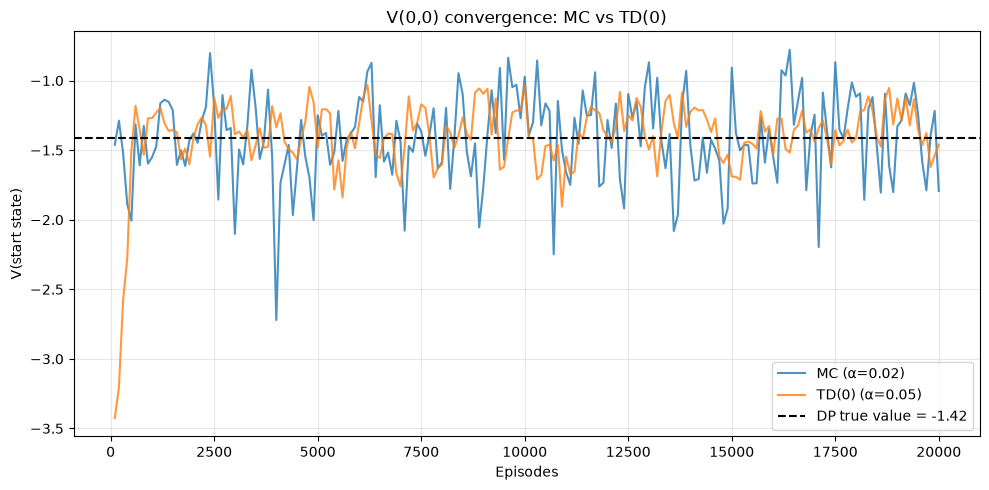

In [14]:
import numpy as np
import matplotlib.pyplot as plt

env = MarsRoverEnv()
_, policy = value_iteration(env)

# Track V(0,0) over episodes for both MC and TD
checkpoints = list(range(0, 20001, 100))  # every 100 episodes

# --- MC tracking ---
V_mc = np.zeros(env.observation_space.n)
mc_trace = []

for ep in range(1, 20001):
    episode = []
    s, _ = env.reset()
    for _ in range(100):
        a = policy[s]
        s_next, reward, terminated, truncated, _ = env.step(a)
        episode.append((s, reward))
        s = s_next
        if terminated or truncated:
            break
    G = 0.0
    for s, reward in reversed(episode):
        G = reward + GAMMA * G
        V_mc[s] = V_mc[s] + 0.02 * (G - V_mc[s])
    if ep % 100 == 0:
        mc_trace.append(V_mc[0])

# --- TD tracking ---
V_td = np.zeros(env.observation_space.n)
td_trace = []

for ep in range(1, 20001):
    s, _ = env.reset()
    for _ in range(100):
        a = policy[s]
        s_next, reward, terminated, truncated, _ = env.step(a)
        target = reward + GAMMA * V_td[s_next] * (1 - terminated)
        V_td[s] = V_td[s] + 0.05 * (target - V_td[s])
        s = s_next
        if terminated or truncated:
            break
    if ep % 100 == 0:
        td_trace.append(V_td[0])

# --- DP true value ---
V_dp, _ = value_iteration(env)
dp_value = V_dp[0]

# --- Plot ---
episodes = checkpoints[1:]  # skip 0
plt.figure(figsize=(10, 5))
plt.plot(episodes, mc_trace, label="MC (α=0.02)", alpha=0.8)
plt.plot(episodes, td_trace, label="TD(0) (α=0.05)", alpha=0.8)
plt.axhline(dp_value, color='black', linestyle='--', label=f"DP true value = {dp_value:.2f}")
plt.xlabel("Episodes")
plt.ylabel("V(start state)")
plt.title("V(0,0) convergence: MC vs TD(0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart clearly shows:

**MC (blue) is noisier** — it swings widely from about -0.7 to -3.0 throughout the entire 20k episodes. Even at 20k, it still has large spikes. This is because MC uses the full return G (sum of all rewards in an episode), which has high variance — one bad episode that hits a crater produces a very negative G that yanks V(0,0) down.

**TD(0) (orange) settles faster** — it stabilizes in the -1.2 to -1.8 range after roughly 3000-5000 episodes with tighter oscillations. TD only uses the one-step target `r + γV(s')`, which is a lower-variance signal since it bootstraps off the current estimate rather than waiting for the entire noisy episode to play out.

**Summary:**

| | MC | TD(0) |
|---|---|---|
| Variance | High (full-episode returns) | Lower (one-step bootstrap) |
| Bias | None (uses true returns) | Some (bootstraps off imperfect V) |
| Settles | Slowly, still noisy at 20k | Faster, ~3-5k episodes |
| Spikes | Down to -3.0+ | Rarely below -2.0 |

This is the classic **bias-variance tradeoff**: MC is unbiased but high variance; TD is biased (early on) but low variance, so it converges to a usable estimate faster in practice.

### Explain. In one short paragraph, tie the picture to what each method’s target is (full return vs one step + a bootstrap)

MC's target is the **full episode return** `G = r₁ + γr₂ + γ²r₃ + ...` — a sum of many stochastic steps, so one unlucky slip into a crater makes G swing wildly negative, producing the large blue spikes. TD(0)'s target is just **one reward plus a bootstrap** `r + γV(s')` — a single step of randomness smoothed by the current value estimate, which acts as a stabilizer. That's why the orange line hugs the dashed truth more tightly: it never sees the full cascade of noise from an entire episode, only one step's worth at a time.

## Problem 4 — Build your own world

Invent a different small environment as a gymnasium.Env with at least one stochastic transition — e.g.
a delivery drone dodging wind gusts, an elevator serving random floor calls, or a warehouse robot
on a slippery floor. Run at least one of DP / MC / TD on it and show the value function. Keep it small
enough to print.

In [15]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from typing import Tuple, Set, Dict

# --- Delivery Drone Environment ---
# 4x4 grid world:
#   - Drone starts at (0,0), aims to reach delivery location at (3,3).
#   - Wind: On each move, 20% (WIND) chance of being blown in a random direction (including intended).
#   - No-fly/crash zones at (1,1) and (2,3): entering these means instant crash (terminal, reward -15).
#   - Reaching delivery point is terminal and gives reward +20.
#   - Each non-terminal move costs -1, until terminal state is reached.

# Grid size (number of rows/columns)
DRONE_GRID: int = 4

# Coordinates of the goal (delivery point)
DRONE_GOAL: Tuple[int, int] = (3, 3)

# Set of coordinates that are no-fly/crash zones
DRONE_NO_FLY: Set[Tuple[int, int]] = {(1, 1), (2, 3)}

# Probability of wind blowing the drone off course
WIND: float = 0.2

# Discount factor for future rewards
DRONE_GAMMA: float = 0.95

# Mapping of action identifiers to movement deltas:
# 0: up, 1: right, 2: down, 3: left
# Each value is a (delta_row, delta_col) tuple.
DRONE_MOVES: Dict[int, Tuple[int, int]] = {
    0: (-1, 0),   # up
    1: (0, 1),    # right
    2: (1, 0),    # down
    3: (0, -1),   # left
}


In [16]:
class DeliveryDroneEnv(gym.Env):
    """
    A delivery drone dodging wind gusts in a 4x4 grid world.

    - The drone starts at (0, 0).
    - The goal is to reach the delivery location (3, 3).
    - No-fly/crash zones: (1, 1) and (2, 3) — entering is terminal with reward -15.
    - There is a stochastic wind: on every move, with 20% probability, the drone
      is blown in a random direction (chosen uniformly from all possible directions,
      including the intended one).
    - Reaching the delivery location is terminal with reward +20.
    - Every non-terminal move costs -1.
    """

    observation_space: gym.spaces.Discrete
    action_space: gym.spaces.Discrete
    goal: int
    no_fly: Set[int]
    terminals: Set[int]
    P: Dict[int, Dict[int, list[Tuple[float, int, float, bool]]]]
    s: int  # Current state index

    def __init__(self) -> None:
        super().__init__()
        # There are DRONE_GRID * DRONE_GRID observed states (flattened index)
        self.observation_space = spaces.Discrete(DRONE_GRID * DRONE_GRID)
        # Four actions: 0=up, 1=right, 2=down, 3=left
        self.action_space = spaces.Discrete(len(DRONE_MOVES))
        # Flattened index for the delivery goal state
        self.goal = DRONE_GRID * DRONE_GOAL[0] + DRONE_GOAL[1]
        # Set of flattened indices for no-fly zones (crash sites)
        self.no_fly = {DRONE_GRID * r + c for r, c in DRONE_NO_FLY}
        # Terminal states are the goal and no-fly zones
        self.terminals = self.no_fly | {self.goal}
        # P[s][a] = list of (prob, s', reward, terminated) tuples (model of the MDP)
        self.P = self._build_model()

    def _move(self, s: int, a: int) -> int:
        """
        Given current state index (s) and action (a), returns the resulting state index after applying action.
        Movement is bounded by the grid: cannot move off the grid.
        Args:
            s (int): Current state as a flat index.
            a (int): Action id (0=up, 1=right, 2=down, 3=left).
        Returns:
            int: Next state as flattened index after movement.
        """
        r, c = divmod(s, DRONE_GRID)  # Get (row, col) from 1D state id
        dr, dc = DRONE_MOVES[a]
        # Clamp new position to grid bounds
        nr = min(max(r + dr, 0), DRONE_GRID - 1)
        nc = min(max(c + dc, 0), DRONE_GRID - 1)
        return nr * DRONE_GRID + nc

    def _reward(self, s_next: int) -> float:
        """
        Computes the reward upon arrival in s_next.
        Args:
            s_next (int): Next state as flattened index.
        Returns:
            float: Reward (+20 for goal, -15 for crash, -1 otherwise).
        """
        if s_next == self.goal:
            return 20.0
        elif s_next in self.no_fly:
            return -15.0
        else:
            return -1.0

    def _build_model(self) -> Dict[int, Dict[int, list[Tuple[float, int, float, bool]]]]:
        """
        Constructs the environment transition dynamics P: for every state-action pair,
        lists the possible (prob, next_state, reward, terminated) transitions.

        Returns:
            Dict[int, Dict[int, list[Tuple[float, int, float, bool]]]]:
                Nested dictionary. P[s][a] = list of (prob, next_state, reward, terminated)
        """
        from collections import defaultdict
        P: Dict[int, Dict[int, list[Tuple[float, int, float, bool]]]] = defaultdict(dict)

        for s in range(DRONE_GRID * DRONE_GRID):
            for a in range(self.action_space.n):
                if s in self.terminals:
                    # Terminal state: remain in place, zero reward, always done.
                    P[s][a] = [(1.0, s, 0.0, True)]
                    continue

                outcomes: Dict[int, float] = {}
                # Wind model:
                #   - Intended action gets probability (1 - WIND) + (WIND/4)
                #   - Each other action (including the intended one) gets additional WIND/4
                intended_prob: float = (1 - WIND) + WIND / 4
                other_prob: float = WIND / 4

                # Try all directions for random wind displacement.
                for d in range(4):
                    s_next = self._move(s, d)
                    # Intended action gets extra probability mass
                    prob = intended_prob if d == a else other_prob
                    outcomes[s_next] = outcomes.get(s_next, 0.0) + prob

                # Translate outcomes to Gymnasium MDP transition tuples
                P[s][a] = [
                    (
                        prob,                     # Probability of transition
                        s_next,                   # Next state index
                        self._reward(s_next),     # Reward after entering next state
                        s_next in self.terminals  # Terminated flag
                    )
                    for s_next, prob in outcomes.items()
                ]

        return P

    def reset(self, seed: int = None, options=None) -> Tuple[int, dict]:
        """
        Resets the environment to the starting state.
        Args:
            seed (int, optional): Random seed.
            options: Unused, for compatibility.
        Returns:
            Tuple[int, dict]: The starting state index, and extra info dict.
        """
        super().reset(seed=seed)
        self.s = 0  # Always start at (0,0)
        return self.s, {}

    def step(self, action: int) -> Tuple[int, float, bool, bool, dict]:
        """
        Perform an action in the environment using the model P.

        Args:
            action (int): The action to take in the current state.

        Returns:
            Tuple: (next_state, reward, terminated, truncated, info)
                - next_state (int): index of resulting state
                - reward (float): reward from transition
                - terminated (bool): whether the episode ended (goal/crash)
                - truncated (bool): always False (no time-limit support here)
                - info (dict): extra info, always empty
        """
        tr = self.P[self.s][action]  # Transitions: list of (prob, next_state, reward, done)
        probs = [t[0] for t in tr]
        i = np.random.choice(len(tr), p=probs)
        _, s_next, r, done = tr[i]
        self.s = s_next
        return s_next, r, done, False, {}


In [17]:
# --- Run Value Iteration ---
from typing import Tuple
import numpy as np

def drone_value_iteration(
    env, 
    gamma: float = DRONE_GAMMA, 
    theta: float = 1e-6
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run value iteration for the DeliveryDroneEnv.

    Args:
        env: DeliveryDroneEnv, must have .P (env model), .observation_space, .action_space.
        gamma (float): Discount factor for future rewards.
        theta (float): Convergence threshold (stops when max value change < theta).

    Returns:
        Tuple[np.ndarray, np.ndarray]:
            - V: Value function V[s] = optimal value of each state.
            - policy: Greedy policy (integer action) for each state.
    """
    n: int = env.observation_space.n                   # Number of states in the environment
    V: np.ndarray = np.zeros(n)                        # Initialize all state values to zero

    while True:
        delta = 0.0                                    # Tracks max value change across all states
        for s in range(n):
            v_old: float = V[s]                        # Store current value for change tracking
            q_vals = []
            # For each action, compute expected Q-value using the env model P
            for a in range(env.action_space.n):
                # env.P[s][a]: list of (probability, next_state, reward, terminated)
                q: float = sum(
                    p * (r + gamma * V[sn] * (1 - done))     # Bellman update for non-terminal transitions
                    for p, sn, r, done in env.P[s][a]
                )
                q_vals.append(q)
            V[s] = max(q_vals)                        # Greedily select the best action's value
            delta = max(delta, abs(v_old - V[s]))     # Track the biggest value change this sweep
        if delta < theta:
            break                                     # If values have converged, stop iterating

    # After values have converged, extract deterministic greedy policy
    policy: np.ndarray = np.zeros(n, dtype=int)
    for s in range(n):
        q_vals = []
        for a in range(env.action_space.n):
            q: float = sum(
                p * (r + gamma * V[sn] * (1 - done))
                for p, sn, r, done in env.P[s][a]
            )
            q_vals.append(q)
        policy[s] = int(np.argmax(q_vals))            # Choose the action with the highest Q-value

    return V, policy

In [18]:
# --- Run and display the results of value iteration for DeliveryDroneEnv, with detailed comments and types ---

# Instantiate the environment; type: DeliveryDroneEnv (must provide .P, .observation_space, .action_space)
drone_env: DeliveryDroneEnv = DeliveryDroneEnv()

# Perform value iteration to obtain:
#   V_drone: np.ndarray — the optimal value function for each state
#   pi_drone: np.ndarray — the greedy (deterministic) policy: action for each state
V_drone: np.ndarray
pi_drone: np.ndarray
V_drone, pi_drone = drone_value_iteration(drone_env)

# Display the value function in 4x4 grid corresponding to the drone environment layout.
print("Delivery Drone — Value Function (DP):")
# V_drone is a flat array; reshape to (DRONE_GRID, DRONE_GRID) for visualization.
print(np.round(V_drone.reshape(DRONE_GRID, DRONE_GRID), 2))

# Create a mapping from action index to arrow for visualization of the policy.
arrows: dict[int, str] = {0: "^", 1: ">", 2: "v", 3: "<"}  # Up, Right, Down, Left.

# Build a grid of arrow symbols or '.' for terminal states, to visualize policy.
grid: list[str] = []
for s in range(DRONE_GRID * DRONE_GRID):
    if s in drone_env.terminals:
        # If the state is terminal (goal/no-fly), mark with '.'
        grid.append(".")
    else:
        # Otherwise, display arrow corresponding to the greedy action.
        grid.append(arrows[pi_drone[s]])

# Show the greedy policy grid.
print("\nGreedy Policy:")
# Convert grid list to numpy array and reshape for 2D visualization
print(np.array(grid).reshape(DRONE_GRID, DRONE_GRID))

Delivery Drone — Value Function (DP):
[[ 7.23  6.35  9.17  7.51]
 [ 8.96  0.   11.25  8.12]
 [12.25 13.04 15.01  0.  ]
 [14.4  16.65 19.27  0.  ]]

Greedy Policy:
[['v' '>' 'v' '<']
 ['v' '.' 'v' '<']
 ['v' 'v' 'v' '.']
 ['>' '>' '>' '.']]


### what S/A/P/R/γ mean in it, and one value-function result.
**Delivery Drone MDP components:**

| Symbol | Meaning | In this environment |
|--------|---------|-------------------|
| **S** | State space | 16 states (4x4 grid, indices 0–15). Each state = drone's position |
| **A** | Action space | 4 actions: up(0), right(1), down(2), left(3) |
| **P** | Transition probability | 85% intended direction, 5% each other direction (wind gusts) |
| **R** | Reward function | +20 delivery, -15 no-fly crash, -1 per move |
| **γ** | Discount factor | 0.95 (future rewards worth 95% of immediate) |

**One value-function result explained — V(3,2) = 19.27:**

From state (3,2), the optimal action is `>` (right toward goal):

The value is high because the drone is one step from the goal with 85% success probability, and even when wind blows it off course, it lands on high-value neighboring states.

## Problem 5 — Short answers 
1. DP read env.P; MC and TD only called env.step(). In a real Mars rover, which of these is realistic,
and why? 
**Answer:** MC and TD are realistic. A real Mars rover doesn't have a perfect model of the terrain — it doesn't know the exact probability of slipping on every rock, or the precise reward for every possible position. It can only try things and observe outcomes (take an action, see where it ends up, get feedback). That's exactly what env.step() provides. DP requires the full transition model P(s'|s,a) which would require perfect knowledge of Martian terrain physics — unrealistic in practice.

2. You hit a crater on episode 1. With MC, when does the state before it learn it was bad? With TD? 
**Answer:** MC: Only learns at the end of the episode. TD: Learns immediately on that step.


3. Everything here found the value of a fixed policy. What one idea turns this into finding the best policy
from experience — and which lecture is that? 
**Answer:** Exploration (acting non-greedily to discover better actions) — specifically, learning Q(s,a) instead of V(s) and using greedy or similar exploration strategies to improve the policy while learning. This is control (as opposed to prediction), covered in Lecture 2 (Q-learning, SARSA).